# Model B: XGBoost

Planteamos el uso de XGBoost, basado en arboles de decision, debido a la naturaleza no lineal del dataset.

In [1]:
import sys
sys.path.insert(0, "..")

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV


from src.data_loader import load_dataset, get_train_test_split
from src.evaluation import plot_full_evaluation


import xgboost as xgb


## 1. Load Data

In [2]:
df = load_dataset()

# Eliminamos el id, feature no relevante para el modelo
df.drop(columns=['id'], inplace=True)
# Identificamos las features categoricas y numericas para el preprocesamiento
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numeric_features = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']

X_train, X_test, y_train, y_test = get_train_test_split(df)

Loaded dataset: 5110 rows, 12 columns.
Split: train=4088 rows, test=1022 rows (test_size=0.2, seed=13)


## 2. Define Pipeline

Customize the preprocessing steps and estimator for your model.

AUC: 0.8648353909465021
=== XGBoost - scale_pos_weight 19.522088353413654 - max_delta_step 10 ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       972
           1       0.32      0.24      0.27        50

    accuracy                           0.94      1022
   macro avg       0.64      0.61      0.62      1022
weighted avg       0.93      0.94      0.93      1022



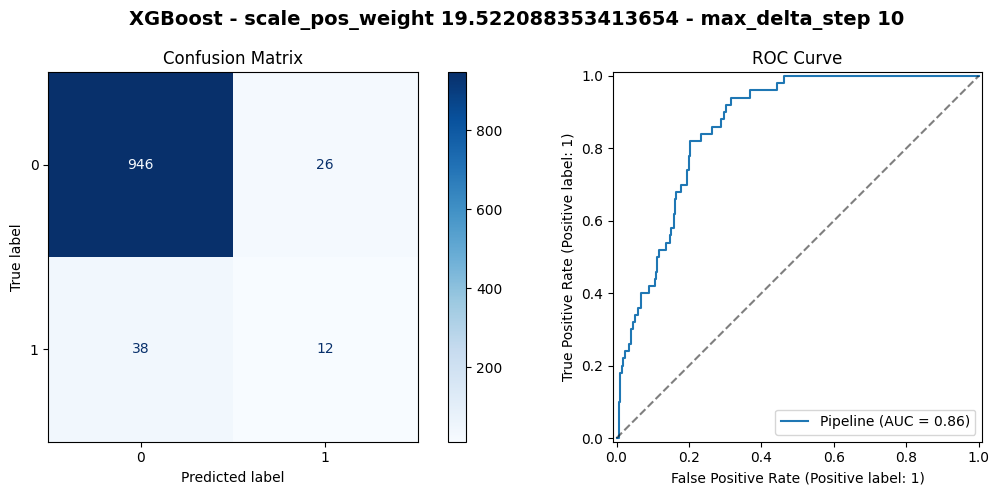

In [3]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# Conocemos que el dataset esta desbalanceado, por lo que aplicamos un scale_pos_weight
scale_pos_weight = (df['stroke'] == 0).sum() / (df['stroke'] == 1).sum()
max_delta_step = 10

# objective
#   "binary:logistic": logistic regression for binary classification, output probability
#   "binary:logitraw": logistic regression for binary classification, output score before logistic transformation
#   "binary:hinge": hinge loss for binary classification. This makes predictions of 0 or 1, rather than producing probabilities.
xgb_regressor = xgb.XGBClassifier(objective='binary:logistic', random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight, max_delta_step=max_delta_step)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", xgb_regressor)
])

pipeline.fit(X_train, y_train)

y_pred_xgb = pipeline.predict(X_test)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_proba))

metrics = plot_full_evaluation(pipeline, X_test, y_test, model_name=f"XGBoost - scale_pos_weight {scale_pos_weight} - max_delta_step {max_delta_step}")


## Interpretacion parcial
Encontramos que XGBoost sin ajuste por hiperparametros no es confiable para identificar la probablidad de un stroke. (f1-score = 0.27 bajo)


## 3. Hyperparameter Search

Utilizando GridSearchCV, busco ajustar del modelo:
- subsample: Controla la fraccion de observaciones para cada iteracion
- eta (learning_rate): Controla la velocidad de aprendizaje
- scale_pos_weight: Ajusta en base al desbalanceo

In [4]:
param_grid = {
    "model__subsample": [0.8, 1.0],
    "model__learning_rate": [0.01, 0.1],
    "model__scale_pos_weight": [10, 15, 20]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

Best params: {'model__learning_rate': 0.01, 'model__scale_pos_weight': 15, 'model__subsample': 0.8}


## 4. Evaluate Best Model

AUC: 0.885
=== XGBoost → Tunned with GridSearchCV ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       972
           1       0.21      0.56      0.30        50

    accuracy                           0.87      1022
   macro avg       0.59      0.72      0.62      1022
weighted avg       0.94      0.87      0.90      1022



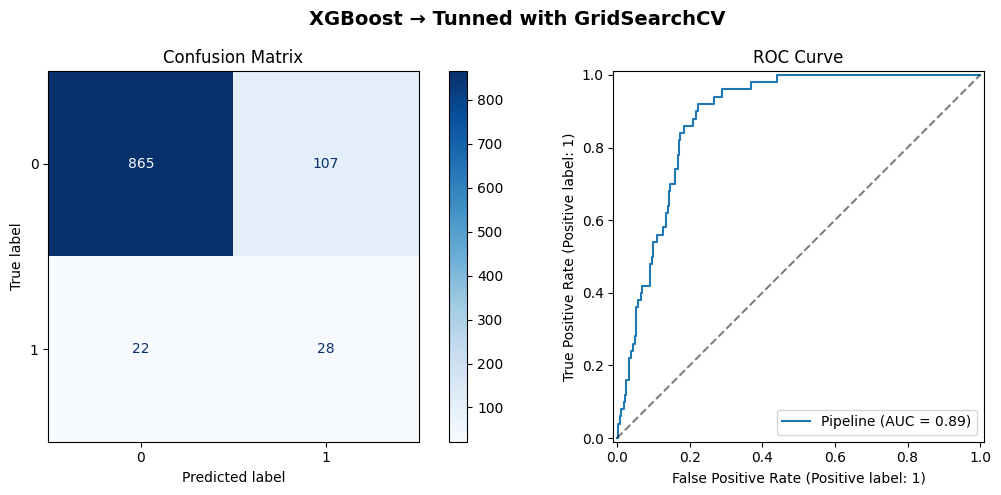

In [5]:
best_model = grid.best_estimator_

y_pred_fitted = best_model.predict(X_test)
y_proba_fitted = best_model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_proba_fitted))

metrics = plot_full_evaluation(best_model, X_test, y_test, model_name="XGBoost → Tunned with GridSearchCV")


Con el nuevo modelo se mejora un poco en poder distinguir las clases 0 y 1 (AUC = 0.88)
Se mejora la detección de la clase 1 (recall: 0.36 vs 0.24)

El modelo logra un equilibrio entre sensibilidad y precisión, mejorando la detección de casos positivos sin incurrir en un aumento extremo de falsos positivos.